In [90]:
# Cell 1: Imports and Constants
import numpy as np
from scipy.special import iv # Modified Bessel function of the first kind (I_0 is iv(0, x))
from scipy.special import roots_legendre # For Gaussian quadrature roots and weights
from scipy.integrate import fixed_quad # Alternative for Gaussian quadrature

# --- Physical Constants ---
# Typical index of refraction for hair
eta = 1.55

# --- Example Parameters (can be changed for analysis) ---
# Melanin concentrations (example values)
rho_e = 0.5 # Eumelanin concentration
rho_p = 0.5 # Pheomelanin concentration

# RGB absorption cross-sections (from paper section 6.1) [cite: 143]
# Units are arbitrary but relative values matter. Proportional to R^2.
sigma_a_e = np.array([0.419, 0.697, 1.37])
sigma_a_p = np.array([0.187, 0.4, 1.05])

# Combined absorption coefficient (mu_a) for RGB
mu_a_rgb = rho_e * sigma_a_e + rho_p * sigma_a_p

# Roughness variance (v = beta^2). Example: beta = 8.1 degrees (paper Fig 4) [cite: 92]
# Longitudinal roughness variance
v_longitudinal = (np.radians(8.1))**2
# Azimuthal roughness variance (can be different, use same for simplicity here)
v_azimuthal = v_longitudinal # or (np.radians(beta_azimuthal))**2

# Cuticle tilt angle (alpha_p) - example, can vary per mode p
alpha_p = np.radians(2) # Example tilt

# Gaussian Quadrature order (higher for smoother surfaces) [cite: 130]
quadrature_order = 35

# Precompute Legendre roots and weights for Gaussian Quadrature over [-1, 1]
# SciPy returns roots (x) and weights (w)
legendre_roots, legendre_weights = roots_legendre(quadrature_order)

In [91]:
# Cell 2: Helper Functions

# Fresnel Reflectance (Schlick's approximation or full form can be used)
# Using the full Fresnel equations for unpolarized light
def fresnel_reflectance(eta_incident, eta_transmitted, cos_theta_incident):
    """Calculates Fresnel reflectance for unpolarized light."""

    cos_theta_incident = np.abs(cos_theta_incident)
    cos_theta_incident = np.clip(cos_theta_incident, a_min=0.0, a_max=1.0)
    # maybe needs clamping

    sin_theta_incident_sq = 1.0 - cos_theta_incident**2
    eta_ratio = eta_incident / eta_transmitted
    sin_theta_transmitted_sq = eta_ratio**2 * sin_theta_incident_sq

    cos_theta_transmitted = np.sqrt(1.0 - sin_theta_transmitted_sq)

    # Parallel polarization
    r_parallel = ((eta_transmitted * cos_theta_incident) - (eta_incident * cos_theta_transmitted)) / \
                 ((eta_transmitted * cos_theta_incident) + (eta_incident * cos_theta_transmitted))
    # Perpendicular polarization
    r_perpendicular = ((eta_incident * cos_theta_incident) - (eta_transmitted * cos_theta_transmitted)) / \
                      ((eta_incident * cos_theta_incident) + (eta_transmitted * cos_theta_transmitted))

    return (r_parallel**2 + r_perpendicular**2) / 2.0

def F(eta_val, cos_theta):
    """Wrapper for Fresnel reflectance assuming air->hair (eta=1 -> eta_val)."""
    # Assumes incident medium is air (eta=1.0)
    return fresnel_reflectance(1.0, eta_val, cos_theta)

# Attenuation factor A(p, h) (Equations 12, 13) [cite: 124, 128]
def A(p, h, eta_prime, mu_a_prime, theta_d):
    """Calculates the attenuation factor A."""
    h = np.clip(h, -1.0 + 1e-6, 1.0 - 1e-6) # Avoid domain errors at h = +/- 1

    # Calculate internal angle gamma_t using Snell's law in the normal plane
    sin_gamma_i = h
    cos_gamma_i = np.sqrt(1.0 - sin_gamma_i**2)
    sin_gamma_t = h / eta_prime
    cos_gamma_t = np.sqrt(np.maximum(0.0, 1.0 - sin_gamma_t**2)) # Use max to avoid sqrt(negative)

    # Fresnel term f (Eq 14 uses a different angle, let's re-evaluate Fresnel based on gamma_i)
    # The angle for Fresnel is the incidence angle on the surface
    # cos(incidence_angle) = cos(theta_d) * cos(gamma_i)
    # Clamp the argument to arccos to [-1, 1]
    cos_incidence_angle_arg = np.cos(theta_d) * cos_gamma_i
    cos_incidence_angle = np.clip(cos_incidence_angle_arg, -1.0, 1.0)
    # print(f"cos_incidence_angle: {cos_incidence_angle}")
    # print(f"eta prime: {eta_prime}")
    # print(f"debug: {zip(eta_prime.tolist(), cos_incidence_angle.tolist())}")
    f = F(eta_prime, cos_incidence_angle) # Note: paper uses eta', but Fresnel usually needs original eta. Using eta_prime per paper Eq 14. Needs verification.
    # Absorption term T(mu_a', h)
    # Path length factor inside hair related to 2*cos(gamma_t) per segment? Paper Eq 14 ref differs slightly.
    # Following T = exp(-mu_a * path_length), path length per segment = 2 * R * cos(gamma_t) / cos(theta_d). With R=1.
    # The paper uses T = exp(-2 * mu_a_prime * (1 + cos(2*gamma_t))) which simplifies from cylindrical geometry. Let's use the paper's form.
    # cos(2*gamma_t) = cos^2(gamma_t) - sin^2(gamma_t) = (1-sin^2(gamma_t)) - sin^2(gamma_t) = 1 - 2*sin^2(gamma_t)
    # So, 1 + cos(2*gamma_t) = 2 * cos^2(gamma_t)
    absorption_term_exponent = -2 * mu_a_prime[:, np.newaxis] * (2 * cos_gamma_t**2)
    T = np.exp(absorption_term_exponent)
    if p == 0: # Special case for R (direct reflection) [cite: 124]
         # Eq 12 uses half angle between incident/reflected vectors in 3D
         # For simplified model, might approximate using theta_d or assume it's handled by N_p's cos factor
         # Let's assume N_0 handles the geometry factor and just use Fresnel at the reflection point.
         # The angle here is based on the half angle of the full 3D vectors omega_i, omega_r.
         # This requires the full vectors, not just angles.
         # Approximation: Use the angle derived for f above.
        return f
    else: # For p >= 1 (TT, TRT, ...) [cite: 128]
        r = ((1.0 - f)**2) * (f**(p - 1)) * (T**p)
        return r


# Gaussian Detector D_p (Equation 11) [cite: 119]
# Implemented using a limited sum as suggested in paper Sec 6. [cite: 128]
def gaussian_detector(beta_p, phi_delta, k_limit=5):
    """Calculates the wrapped Gaussian detector D_p."""
    variance = beta_p**2
    if variance < 1e-6: # Avoid division by zero for smooth surface
        # Approximate Dirac delta if variance is tiny
        # A proper implementation would return infinity at phi_delta=0 and 0 otherwise
        # For numerical purposes, return a large value if close to 0, else 0.
        return np.where(np.abs(phi_delta % (2 * np.pi)) < 1e-3, 1e6, 0.0)

    norm_factor = 1.0 / (np.sqrt(2 * np.pi) * beta_p) # Normalization for a single Gaussian
    total_val = 0.0
    for k in range(-k_limit, k_limit + 1):
        angle = phi_delta - 2 * np.pi * k
        total_val += np.exp(-angle**2 / (2 * variance))

    # The paper mentions this relates to Elliptic Theta functions,
    # suggesting the normalization might differ from sum of simple Gaussians.
    # Let's stick to the sum of Gaussians approach implied by Eq 11 for now.
    # Need to ensure it integrates to 1 over [0, 2pi]. This sum doesn't guarantee that.
    # A common practice is to normalize the *result* numerically if needed,
    # or use the proper Theta function implementation if accuracy is paramount.
    # For now, return the unnormalized sum * norm_factor.
    return norm_factor * total_val

# Azimuthal shift Phi(p, h) (Equation 8) [cite: 95]
def Phi(p, h, eta_prime):
    """Calculates the azimuthal shift angle Phi."""
    h = np.clip(h, -1.0 + 1e-6, 1.0 - 1e-6) # Avoid domain errors
    gamma_t = np.arcsin(np.clip(h / eta_prime, -1.0, 1.0)) # Clip argument for safety
    return 2 * p * gamma_t - 2 * np.arcsin(h) + p * np.pi

In [92]:
# Cell 3: Core Scattering Functions (Mp and Np)

# Longitudinal Scattering Function M_p (Equation 7) [cite: 84]
# Note: requires modified Bessel function I_0
def M_p(v, theta_i, theta_r, alpha_p_shift=0):
    """Calculates the longitudinal scattering function M_p."""
    # Apply cuticle tilt shift
    theta_r_shifted = theta_r - alpha_p_shift

    # Ensure angles are within valid range [-pi/2, pi/2] if needed, though paper doesn't explicitly state clipping here.
    # Clamp arguments to avoid domain errors in trig functions if necessary
    theta_i = np.clip(theta_i, -np.pi/2 + 1e-6, np.pi/2 - 1e-6)
    theta_r_shifted = np.clip(theta_r_shifted, -np.pi/2 + 1e-6, np.pi/2 - 1e-6)

    cos_theta_i = np.cos(theta_i)
    cos_theta_r = np.cos(theta_r_shifted)
    sin_theta_i = np.sin(theta_i)
    sin_theta_r = np.sin(theta_r_shifted)

    # Check for zero variance (smooth surface) -> Dirac delta
    if v < 1e-6:
        # Return large value if theta_r_shifted is near -theta_i, else 0
        # Need a tolerance delta
        delta_tolerance = np.radians(0.1) # e.g., 0.1 degrees
        return np.where(np.abs(theta_r_shifted + theta_i) < delta_tolerance, 1e6 / delta_tolerance, 0.0)

    # Argument for Bessel function I_0
    bessel_arg = (cos_theta_i * cos_theta_r) / v
    # Argument for exponential
    exp_arg = (sin_theta_i * sin_theta_r) / v # Note: paper appendix uses +sin(theta_i)sin(theta_r) but main Eq 7 uses cos(-theta_i) which implies -sin(theta_i)sin(theta_r) if derived carefully. Let's re-check derivation.
    # Appendix A derivation: G(x) average over specular cone at -theta_i.
    # If x = view direction (theta_r), P = specular reflection (-theta_i)
    # x . P = cos(theta_r)cos(-theta_i)cos(dphi) + sin(theta_r)sin(-theta_i)
    #       = cos(theta_r)cos(theta_i)cos(dphi) - sin(theta_r)sin(theta_i)
    # Integrating cos(dphi) gives I0 term. The second term remains.
    # So exp_arg should be (-sin_theta_i * sin_theta_r) / v
    exp_arg = (-sin_theta_i * sin_theta_r) / v

    # Avoid potential overflow in csch(1/v) for small v
    # csch(x) = 1 / sinh(x). For large x, sinh(x) approx e^x / 2. So csch(x) approx 2 * e^(-x)
    # Here x = 1/v. csch(1/v) approx 2 * exp(-1/v) for large 1/v (small v)
    csch_val = 0.0
    if 1/v > 700: # sinh overflows around e^709
         csch_val = 2.0 * np.exp(-1.0 / v)
    else:
         csch_val = 1.0 / np.sinh(1.0 / v)

    bessel_val = iv(0, bessel_arg) # I_0(x) = iv(0, x)

    # Combine terms according to Equation 7 [cite: 84]
    m_val = (csch_val / (2.0 * v)) * np.exp(exp_arg) * bessel_val
    return m_val


# Azimuthal Scattering Function N_p (Equation 10) [cite: 113]
# Evaluated using Gaussian Quadrature
def N_p(p, phi, theta_i, theta_r, eta_val, mu_a_rgb_val, v_azimuthal_val, beta_azimuthal_val, quadrature_roots, quadrature_weights):
    """Calculates the azimuthal scattering function N_p using Gaussian Quadrature."""
    theta_d = (theta_r - theta_i) / 2.0
    # theta_h = (theta_r + theta_i) / 2.0 # Not directly needed for Np calculation itself

    # Modified index of refraction eta' (Eq before Eq 8) [cite: 93]
    sin_theta_i = np.sin(theta_i)
    cos_theta_d = np.cos(theta_d)
    # Clamp argument under sqrt to avoid domain error
    eta_prime_arg_sq = eta_val**2 - sin_theta_i**2
    eta_prime_arg = np.sqrt(np.maximum(0.0, eta_prime_arg_sq))
    eta_prime = eta_prime_arg / cos_theta_d

    # Reduced absorption mu_a' (Section 6, after Eq 14) [cite: 128]
    cos_theta_i = np.cos(theta_i) # Paper uses cos(theta_t) but that depends on h. Using cos(theta_i) as approximation or per Zinke? Revisit paper. Text says mu_a' = mu_a / cos(theta_d) but uses theta_i in eta' derivation... Using cos(theta_d) based on text after Eq 14.
    mu_a_prime = mu_a_rgb_val / cos_theta_d

    # Integrand for Gaussian Quadrature
    def integrand(h_val):
        attenuation = A(p, h_val, eta_prime, mu_a_prime, theta_d)
        phi_shift = Phi(p, h_val, eta_prime)
        detector = gaussian_detector(beta_azimuthal_val, phi - phi_shift)
        return attenuation * detector

    # Perform Gaussian Quadrature over h in [-1, 1]
    # Map roots/weights from [-1, 1] to integrand evaluation
    # integral = sum(weights[j] * integrand(roots[j]))
    # The factor 1/2 in Eq 10 comes from dh range being 2. GQ handles this.
    # However, the paper integrates from -1 to 1, range is 2. SciPy GQ assumes [-1,1].
    # integral approx sum(w_i * f(x_i)). If range is [-1, 1], this is correct.
    # Let's confirm Eq 10: Np = 1/2 * integral_{-1}^{1} ... dh
    h_vals = quadrature_roots # Roots are already in [-1, 1]
    quad = quadrature_weights * integrand(h_vals)
    integral_val = np.sum(quad, axis=-1)

    # Apply the 1/2 factor from Equation 10 [cite: 113]
    n_p_val = 0.5 * integral_val
    return n_p_val

Input angles (deg): theta_i=29.999999999999996, phi_i=0.0
Output angles (deg): theta_r=-25.0, phi_r=150.0
Calculated Reflectance (RGB): [0.39141934 0.18470296 0.06871117]


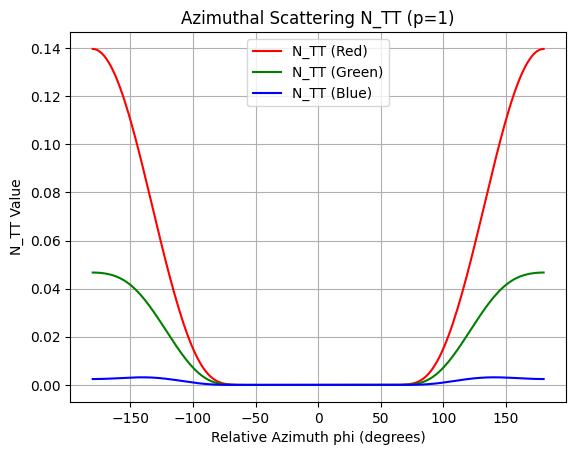

In [93]:
# Cell 4: Full Model Evaluation (Example)

def hair_bsdf(theta_i, phi_i, theta_r, phi_r, eta_val, mu_a_rgb_val, v_long_val, v_azim_val, alpha_p_val, max_p=3):
    """Calculates the full BSDF by summing contributions from p=0 to max_p."""

    phi = phi_r - phi_i # Relative azimuth

    total_reflectance_rgb = np.zeros_like(mu_a_rgb_val) # Initialize for RGB

    # Precompute some values
    beta_azim_val = np.sqrt(v_azim_val)

    # Calculate Legendre roots/weights once if not passed (or pass them)
    q_roots, q_weights = roots_legendre(quadrature_order)

    # Sum contributions from different paths p
    for p in range(max_p + 1): # Iterate from R (p=0) up to max_p
        # --- Longitudinal part ---
        # Use separate roughness/tilt per mode p if desired, else use common values
        # Example: Use common v_long_val and alpha_p_val for all p
        Mp = M_p(v_long_val, theta_i, theta_r, alpha_p_shift=alpha_p_val) # Assuming alpha_p is same for all modes here
        # --- Azimuthal part ---
        # Roughness beta_p could also vary per mode. Using common beta_azim_val here.
        Np_rgb = N_p(p, phi, theta_i, theta_r, eta_val, mu_a_rgb_val, v_azim_val, beta_azim_val, q_roots, q_weights)

        # --- Combine M_p and N_p --- [cite: 33]
        Sp_rgb = Mp * Np_rgb
        total_reflectance_rgb += Sp_rgb

    return total_reflectance_rgb

# --- Example Usage ---
# Incident direction (radians)
theta_i_rad = np.radians(30)
phi_i_rad = np.radians(0)

# Reflected/view direction (radians)
theta_r_rad = np.radians(-25) # Near specular cone -theta_i
phi_r_rad = np.radians(150) # Example azimuthal angle

# Calculate reflectance
reflectance_rgb = hair_bsdf(
    theta_i_rad, phi_i_rad, theta_r_rad, phi_r_rad,
    eta, mu_a_rgb, v_longitudinal, v_azimuthal, alpha_p,
    max_p=3 # Calculate R, TT, TRT, TRRT (p=0, 1, 2, 3)
)

print(f"Input angles (deg): theta_i={np.degrees(theta_i_rad)}, phi_i={np.degrees(phi_i_rad)}")
print(f"Output angles (deg): theta_r={np.degrees(theta_r_rad)}, phi_r={np.degrees(phi_r_rad)}")
print(f"Calculated Reflectance (RGB): {reflectance_rgb}")

# Example: Plotting N_TT across phi
phi_range = np.linspace(-np.pi, np.pi, 200)
n_tt_values = np.array([N_p(1, ph, theta_i_rad, theta_r_rad, eta, mu_a_rgb, v_azimuthal, np.sqrt(v_azimuthal), legendre_roots, legendre_weights) for ph in phi_range])

import matplotlib.pyplot as plt
plt.figure()
plt.plot(np.degrees(phi_range), n_tt_values[:, 0], label='N_TT (Red)', c="red")
plt.plot(np.degrees(phi_range), n_tt_values[:, 1], label='N_TT (Green)', c="green")
plt.plot(np.degrees(phi_range), n_tt_values[:, 2], label='N_TT (Blue)', c="blue")
plt.xlabel("Relative Azimuth phi (degrees)")
plt.ylabel("N_TT Value")
plt.title("Azimuthal Scattering N_TT (p=1)")
plt.legend()
plt.grid(True)
plt.show()